In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import csv
from collections import defaultdict
from statistics import mean, stdev

### Generate Boxplot

In [8]:

def gerar_boxplot_tempo(
    caminho_csv_ou_pasta,
    coluna_algoritmo="algorithm",
    coluna_tempo="time",
    salvar_em="boxplot_tempo_algoritmos.png",
    figsize=(10, 6),
    ordenar_por_mediana=True,
    cores_caixas=None,          # lista de cores ou dict {algoritmo: cor}
    cor_borda="black",
    cor_media="red"
):
    """
    Gera boxplot horizontal do tempo por algoritmo a partir de um CSV
    ou de vários CSVs em uma pasta.

    Parâmetros
    ----------
    caminho_csv_ou_pasta : str
        Caminho para um arquivo .csv ou para uma pasta contendo vários .csv.
    coluna_algoritmo : str
        Nome da coluna com os algoritmos.
    coluna_tempo : str
        Nome da coluna com o tempo.
    salvar_em : str ou None
        Caminho do arquivo de saída da imagem. Se None, não salva.
    figsize : tuple
        Tamanho da figura.
    ordenar_por_mediana : bool
        Se True, ordena os algoritmos pela mediana do tempo.
    cores_caixas : list ou dict ou None
        - Se for lista: usa uma cor por caixa, na ordem dos algoritmos.
        - Se for dict: usa {nome_algoritmo: cor}.
        - Se for None: usa uma cor padrão para todas as caixas.
    cor_borda : str
        Cor da borda das caixas.
    cor_media : str
        Cor do marcador da média.
    """

    caminho = Path(caminho_csv_ou_pasta)

    # Lê um único CSV ou todos os CSVs da pasta
    if caminho.is_file():
        arquivos = [caminho]
    elif caminho.is_dir():
        arquivos = sorted(caminho.glob("*.csv"))
    else:
        raise FileNotFoundError(f"Caminho não encontrado: {caminho}")

    if not arquivos:
        raise ValueError("Nenhum arquivo CSV foi encontrado.")

    dfs = []
    colunas_necessarias = {coluna_algoritmo, coluna_tempo}

    for arq in arquivos:
        df = pd.read_csv(arq)

        faltando = colunas_necessarias - set(df.columns)
        if faltando:
            raise ValueError(
                f"O arquivo '{arq.name}' não possui as colunas necessárias: {faltando}"
            )

        dfs.append(df[[coluna_algoritmo, coluna_tempo]].copy())

    df_final = pd.concat(dfs, ignore_index=True)

    # Converte tempo para numérico
    df_final[coluna_tempo] = pd.to_numeric(df_final[coluna_tempo], errors="coerce")
    df_final = df_final.dropna(subset=[coluna_algoritmo, coluna_tempo])

    if df_final.empty:
        raise ValueError("Após limpeza dos dados, não restaram registros válidos.")

    # Define ordem dos algoritmos
    if ordenar_por_mediana:
        ordem = (
            df_final.groupby(coluna_algoritmo)[coluna_tempo]
            .median()
            .sort_values()
            .index
            .tolist()
        )
    else:
        ordem = sorted(df_final[coluna_algoritmo].unique())

    # Prepara dados para o boxplot
    dados_boxplot = [
        df_final.loc[df_final[coluna_algoritmo] == alg, coluna_tempo].values
        for alg in ordem
    ]

    # Cria figura
    fig = plt.figure(figsize=figsize)

    fig.patch.set_facecolor("white")
    fig.patch.set_edgecolor("black")
    fig.patch.set_linewidth(2)


    bp = plt.boxplot(
        dados_boxplot,
        labels=ordem,
        vert=False,                 # horizontal
        showmeans=False,
        patch_artist=True,          # permite colorir as caixas
        meanprops={
            "marker": "o",
            "markerfacecolor": cor_media,
            "markeredgecolor": cor_media,
            "markersize": 6
        },
        boxprops={"edgecolor": cor_borda},
        whiskerprops={"color": cor_borda},
        capprops={"color": cor_borda},
        medianprops={"color": cor_borda, "linewidth": 2}
    )

    # Define cores das caixas
    if cores_caixas is None:
        for caixa in bp["boxes"]:
            caixa.set_facecolor("lightblue")

    elif isinstance(cores_caixas, list):
        if len(cores_caixas) < len(bp["boxes"]):
            raise ValueError(
                "A lista 'cores_caixas' tem menos cores do que a quantidade de algoritmos."
            )
        for caixa, cor in zip(bp["boxes"], cores_caixas):
            caixa.set_facecolor(cor)

    elif isinstance(cores_caixas, dict):
        for caixa, alg in zip(bp["boxes"], ordem):
            caixa.set_facecolor(cores_caixas.get(alg, "lightblue"))

    else:
        raise TypeError("cores_caixas deve ser None, list ou dict.")


    ax = plt.gca()
    ax.set_facecolor("#F8F8F8") #f2f2f2
    plt.grid(axis="x", color="white", linestyle="-", linewidth=2.3)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)
    
    plt.xlabel("Tempo", fontsize=14, )
    plt.ylabel("Algoritmo", fontsize=14, )
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.tight_layout()

    if salvar_em is not None:
        plt.savefig(salvar_em, dpi=300, bbox_inches="tight")

    plt.show()

    return df_final

C:\Users\giordano.toscano\AppData\Local\Temp\ipykernel_1716\4109899330.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


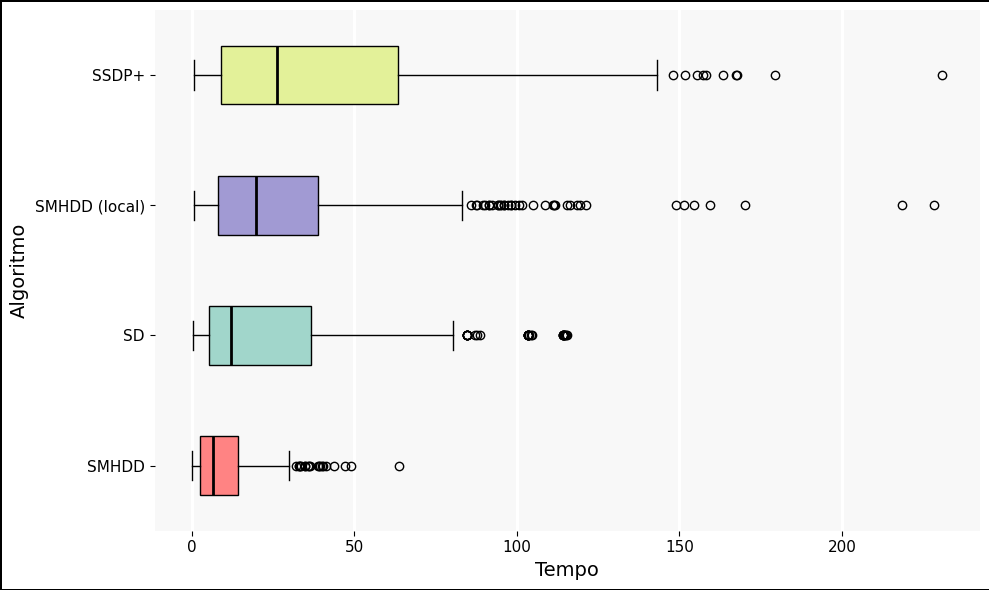

In [19]:
caminho = "BOXPLOT READY\\freq\\results-freq-8-binary.csv"
df = gerar_boxplot_tempo(
    caminho_csv_ou_pasta=caminho,
    salvar_em="boxplot-time_freq_8_binary_results.png",
    cores_caixas=["#FF8383", "#A1D6CB", "#A19AD3", "#E3F199"]
)

C:\Users\giordano.toscano\AppData\Local\Temp\ipykernel_1716\4109899330.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


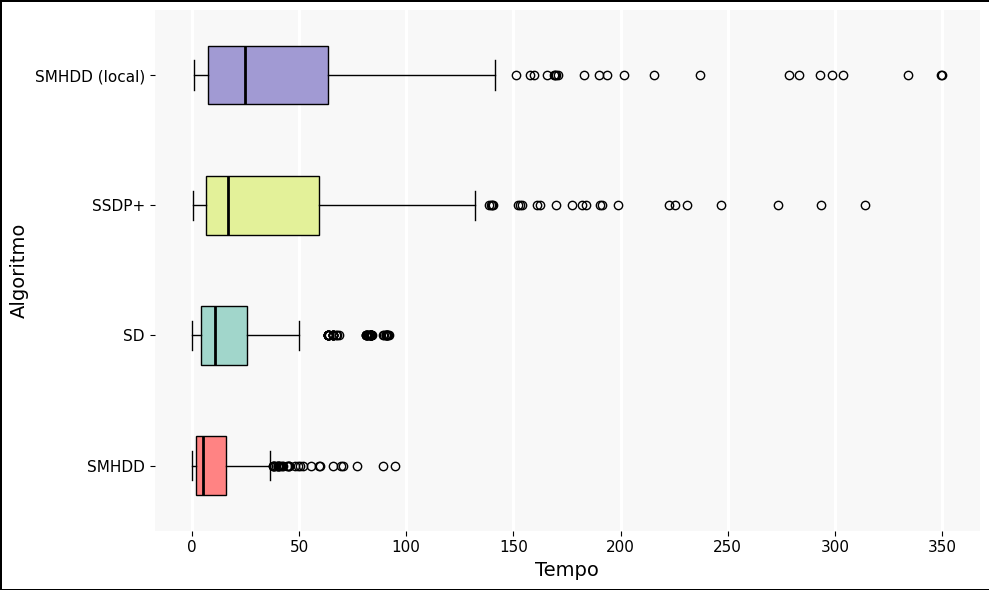

In [18]:
caminho = "BOXPLOT READY\\width\\results-width-8-binary.csv"
df = gerar_boxplot_tempo(
    caminho_csv_ou_pasta=caminho,
    salvar_em="boxplot-time_width_8_binary_results.png",
    cores_caixas=["#FF8383", "#A1D6CB", "#E3F199", "#A19AD3"]
)

### Generate aggregated results

In [5]:
# ==========================================
# CONFIGURAÇÃO
# ==========================================
INPUT_ROOT = Path("complete_results\\num_results")
OUTPUT_ROOT = Path("complete_results\\num_aggregated_results")


def format_output_filename(input_name: str) -> str:
    """
    Exemplo:
      simulation-results_wraccn_width-4_binary.csv
    vira:
      aggregated-results_wraccn_width-4_binary.csv
    """
    prefix = "simulation-results_"
    if input_name.startswith(prefix):
        return input_name.replace(prefix, "aggregated-results_", 1)
    return f"aggregated-{input_name}"


def safe_float(value: str) -> float:
    return float(value.strip())


def aggregate_csv(input_csv: Path, output_csv: Path) -> tuple[int, int]:
    """
    Lê um CSV original e gera o correspondente agregado.
    Retorna:
      (quantidade_de_linhas_lidas, quantidade_de_algoritmos_agregados)
    """
    output_csv.parent.mkdir(parents=True, exist_ok=True)

    # Estrutura:
    # data[algorithm] = {
    #   "quality": [...],
    #   "supp+": [...],
    #   "time": [...]
    # }
    data = defaultdict(lambda: {
        "quality": [],
        "supp+": [],
        "time": []
    })

    total_rows = 0

    with input_csv.open("r", encoding="utf-8-sig", newline="") as fin:
        reader = csv.DictReader(fin)

        if reader.fieldnames is None:
            raise ValueError(f"Arquivo sem cabeçalho: {input_csv}")

        required_columns = {"algorithm", "quality", "supp+", "time"}
        missing = required_columns - set(reader.fieldnames)
        if missing:
            raise ValueError(
                f"Arquivo {input_csv} não possui as colunas esperadas. "
                f"Faltando: {sorted(missing)}"
            )

        for row in reader:
            total_rows += 1
            algorithm = row["algorithm"].strip()

            data[algorithm]["quality"].append(safe_float(row["quality"]))
            data[algorithm]["supp+"].append(safe_float(row["supp+"]))
            data[algorithm]["time"].append(safe_float(row["time"]))

    with output_csv.open("w", encoding="utf-8-sig", newline="") as fout:
        fieldnames = [
            "algorithm",
            "average_quality",
            "standard_deviation",
            "average_supp+",
            "average_time",
        ]
        writer = csv.DictWriter(fout, fieldnames=fieldnames)
        writer.writeheader()

        for algorithm in sorted(data.keys()):
            qualities = data[algorithm]["quality"]
            supps = data[algorithm]["supp+"]
            times = data[algorithm]["time"]

            avg_quality = mean(qualities)
            avg_supp = mean(supps)
            avg_time = mean(times)

            # Desvio padrão amostral da qualidade
            std_quality = stdev(qualities) if len(qualities) > 1 else 0.0

            writer.writerow({
                "algorithm": algorithm,
                "average_quality": f"{avg_quality:.2f}",
                "standard_deviation": f"{std_quality:.2f}",
                "average_supp+": f"{avg_supp:.2f}",
                "average_time": f"{avg_time:.2f}",
            })

    return total_rows, len(data)


def main():
    if not INPUT_ROOT.exists():
        raise FileNotFoundError(f"Pasta de entrada não encontrada: {INPUT_ROOT.resolve()}")

    csv_files = sorted(INPUT_ROOT.rglob("*.csv"))

    if not csv_files:
        print(f"Nenhum CSV encontrado em: {INPUT_ROOT.resolve()}")
        return

    total_files = 0
    total_rows = 0
    total_algorithms = 0

    for input_csv in csv_files:
        relative_path = input_csv.relative_to(INPUT_ROOT)
        output_relative = relative_path.with_name(format_output_filename(relative_path.name))
        output_csv = OUTPUT_ROOT / output_relative

        rows_read, algorithms_count = aggregate_csv(input_csv, output_csv)

        total_files += 1
        total_rows += rows_read
        total_algorithms += algorithms_count

        print(
            f"[OK] {input_csv} -> {output_csv} | "
            f"linhas lidas: {rows_read} | algoritmos agregados: {algorithms_count}"
        )

    print("\n===== RESUMO =====")
    print(f"Arquivos processados: {total_files}")
    print(f"Total de linhas lidas: {total_rows}")
    print(f"Total de grupos (algoritmos): {total_algorithms}")
    print(f"Saída gravada em: {OUTPUT_ROOT.resolve()}")


if __name__ == "__main__":
    main()

[OK] complete_results\num_results\FREQ\QG\simulation-results_qg_freq-2_nominal.csv -> complete_results\num_aggregated_results\FREQ\QG\aggregated-results_qg_freq-2_nominal.csv | linhas lidas: 200 | algoritmos agregados: 1
[OK] complete_results\num_results\FREQ\QG\simulation-results_qg_freq-4_binary.csv -> complete_results\num_aggregated_results\FREQ\QG\aggregated-results_qg_freq-4_binary.csv | linhas lidas: 200 | algoritmos agregados: 1
[OK] complete_results\num_results\FREQ\QG\simulation-results_qg_freq-4_nominal.csv -> complete_results\num_aggregated_results\FREQ\QG\aggregated-results_qg_freq-4_nominal.csv | linhas lidas: 200 | algoritmos agregados: 1
[OK] complete_results\num_results\FREQ\QG\simulation-results_qg_freq-8_binary.csv -> complete_results\num_aggregated_results\FREQ\QG\aggregated-results_qg_freq-8_binary.csv | linhas lidas: 200 | algoritmos agregados: 1
[OK] complete_results\num_results\FREQ\QG\simulation-results_qg_freq-8_nominal.csv -> complete_results\num_aggregated_re

### Unify by width and freq

In [ ]:
def merge_test_results(results_dir="results_cat"):
    results_dir = Path(results_dir)

    output_width = results_dir / "results-width.csv"
    output_freq = results_dir / "results-freq.csv"

    # Procura CSVs em toda a árvore da pasta results
    all_csv_files = [
        f for f in results_dir.rglob("*.csv")
        if f.name not in {"results-width.csv", "results-freq.csv"}
    ]

    # Separa pelos nomes dos arquivos
    width_files = sorted([f for f in all_csv_files if "_width-" in f.name])
    freq_files  = sorted([f for f in all_csv_files if "_freq-" in f.name])

    def merge_files(file_list, output_file):
        if not file_list:
            print(f"Nenhum arquivo encontrado para gerar {output_file.name}")
            return

        header_written = False
        expected_header = None

        with output_file.open("w", newline="", encoding="utf-8") as fout:
            writer = csv.writer(fout)

            for file_path in file_list:
                with file_path.open("r", newline="", encoding="utf-8") as fin:
                    reader = csv.reader(fin)

                    try:
                        header = next(reader)
                    except StopIteration:
                        # arquivo vazio
                        continue

                    if expected_header is None:
                        expected_header = header
                    elif header != expected_header:
                        raise ValueError(
                            f"Header diferente encontrado em {file_path}\n"
                            f"Esperado: {expected_header}\n"
                            f"Obtido:   {header}"
                        )

                    if not header_written:
                        writer.writerow(header)
                        header_written = True

                    writer.writerows(reader)

        print(f"Arquivo gerado: {output_file}")
        print(f"Total de arquivos usados: {len(file_list)}")

    merge_files(width_files, output_width)
    merge_files(freq_files, output_freq)


Nenhum arquivo encontrado para gerar results-width.csv
Nenhum arquivo encontrado para gerar results-freq.csv


In [9]:

# Exemplo de uso
merge_test_results("final_results\\Numerical\\results")

Arquivo gerado: final_results\Numerical\results\results-width.csv
Total de arquivos usados: 10
Arquivo gerado: final_results\Numerical\results\results-freq.csv
Total de arquivos usados: 10
